# EDA – Daniela's Disease Sections

**Diseases analyzed:** High Cholesterol · Emphysema/Lungs · Thyroid

---

## What is Point-Biserial Correlation?

Point-biserial correlation measures the strength and direction of the relationship between a **continuous variable** (e.g. age, BMI) and a **binary variable** (e.g. has disease = 1, no disease = 0).

It is mathematically equivalent to Pearson correlation when one variable is binary, and produces a value between **-1 and +1**:

- **+1** → the feature is perfectly associated with having the disease (higher values → more likely to have the disease)
- **-1** → the feature is perfectly associated with *not* having the disease
- **0** → no linear relationship

A **p-value < 0.05** indicates the correlation is statistically significant (i.e., unlikely to be due to random chance).

We use this method here to identify which lifestyle, demographic, and questionnaire features are most associated with each disease — without using any lab/blood test results.

In [1]:
%matplotlib inline

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from scipy.stats import pointbiserialr
import warnings
warnings.filterwarnings('ignore')

# ── Load dataset ──────────────────────────────────────────────────────────────
df = pd.read_csv("../data/processed/nhanes_merged_adults_final.csv")
print(f"Dataset shape: {df.shape}")
print(f"Columns: {df.shape[1]}")

Dataset shape: (7437, 868)
Columns: 868


In [2]:
import re

# ── Define lab/blood-test column patterns to EXCLUDE ─────────────────────────
LAB_SUFFIXES = (
    '_mg_dl', '_ng_ml', '_ug_dl', '_u_l', '_g_dl', '_ug_ml',
    '_kpa', '_dbm', '_pct', '_ug_g', '_mg_g', '_nmol_l',
    '_pmol_l', '_umol_l', '_mmol_l', '_iu_l', '_miu_ml',
    '_pg_ml', '_mg_l', '_ng_dl', '_ug_l', '_meq_l',
)

# Broader NHANES lab prefix pattern (covers LBD followed by digit, e.g. LBD2DFLC)
LAB_PREFIX_PATTERN = re.compile(r'^(LBX|LBD|URX|URXU|LBDU|LBDR|LBDB|LBDL|LBDP|LBDV|LBDW|LBDA|SSHE)', re.IGNORECASE)

# Explicitly named lab / imaging columns
EXPLICIT_LAB_COLS = {
    'fasting_glucose_mg_dl', 'insulin_uU_ml', 'total_cholesterol_mg_dl',
    'hdl_cholesterol_mg_dl', 'triglycerides_mg_dl', 'ferritin_ng_ml',
    'serum_iron_ug_dl', 'tibc_ug_dl', 'transferrin_saturation_pct',
    'uacr_mg_g', 'serum_creatinine_mg_dl', 'bun_mg_dl',
    'alt_u_l', 'ast_u_l', 'ggt_u_l', 'alp_u_l',
    'total_bilirubin_mg_dl', 'serum_albumin_g_dl',
    'liver_cap_dbm', 'liver_stiffness_kpa', 'liver_stiffness_iqr_ratio',
    'liver_exam_status', 'liver_valid_measures',
}

# ── Define disease label columns to EXCLUDE ───────────────────────────────────
DISEASE_COLS = {
    'overweight', 'sleep_disorder', 'high_blood_pressure', 'high_cholesterol',
    'diabetes', 'menopause', 'alcohol', 'emphysema_lungs', 'thyroid',
    'anemia', 'liver', 'hepatitis_bc', 'kidney', 'coronary_heart', 'heart_failure',
}

# ── Additional leakage / metadata columns to EXCLUDE ─────────────────────────
EXTRA_EXCLUDE = {
    'nan_count', 'fatigue_binary', 'fatigue_score', 'fatigue_label',
    'fatigue_binary_lenient', 'fatigue_binary_strict', 'fatigue_ordinal',
    'SEQN', 'mec_exam_weight', 'interview_weight',
    'nan_group', 'cluster',
}

# ── Keyword-based leakage filter ──────────────────────────────────────────────
# Columns where the survey question directly asks about a diagnosis or prescription
LEAKAGE_KEYWORDS = [
    'doctor_told', 'ever_told', 'still_have', 'told_to_take',
    'told_to_reduce', 'told_to_control', 'told_to_lose', 'take_prescriptn'
]

def has_leakage_keyword(col):
    col_lower = col.lower()
    return any(kw in col_lower for kw in LEAKAGE_KEYWORDS)

def is_lab_col(col):
    col_lower = col.lower()
    if col in EXPLICIT_LAB_COLS:
        return True
    if any(col_lower.endswith(s) for s in LAB_SUFFIXES):
        return True
    if LAB_PREFIX_PATTERN.match(col):
        return True
    return False

def get_non_lab_features(df, disease_col):
    """Return numeric non-lab, non-leakage feature columns suitable for correlation analysis."""
    exclude = DISEASE_COLS | EXTRA_EXCLUDE | {disease_col}
    features = []
    for col in df.columns:
        if col in exclude:
            continue
        if is_lab_col(col):
            continue
        if has_leakage_keyword(col):
            continue
        if df[col].dtype not in [np.float64, np.float32, np.int64, np.int32, np.int16, np.int8]:
            continue
        features.append(col)
    return features

print("Helper functions defined.")
print(f"Total columns in dataset: {len(df.columns)}")
print(f"Leakage keywords active: {LEAKAGE_KEYWORDS}")

Helper functions defined.
Total columns in dataset: 868
Leakage keywords active: ['doctor_told', 'ever_told', 'still_have', 'told_to_take', 'told_to_reduce', 'told_to_control', 'told_to_lose', 'take_prescriptn']


In [3]:
# ── Shared analysis & plotting functions ─────────────────────────────────────

def compute_correlations(df, disease_col, feature_cols, min_per_group=100):
    """Compute point-biserial correlations between disease_col and each feature."""
    results = []
    disease_series = df[disease_col]

    for col in feature_cols:
        mask = disease_series.notna() & df[col].notna()
        sub = df.loc[mask, [disease_col, col]]

        # Require at least min_per_group observations in each class
        counts = sub[disease_col].value_counts()
        if counts.get(0, 0) < min_per_group or counts.get(1, 0) < min_per_group:
            continue

        try:
            corr, pval = pointbiserialr(sub[disease_col], sub[col])
            if np.isnan(corr):
                continue
            results.append({'feature': col, 'correlation': corr, 'p_value': pval})
        except Exception:
            continue

    result_df = pd.DataFrame(results)
    if result_df.empty:
        return result_df
    result_df['abs_corr'] = result_df['correlation'].abs()
    result_df['significant'] = result_df['p_value'] < 0.05
    return result_df.sort_values('abs_corr', ascending=False).reset_index(drop=True)


def plot_top_correlations(corr_df, title, top_n=20):
    """Horizontal bar chart of top N correlations with diverging color."""
    top = corr_df.head(top_n).copy()
    top = top.sort_values('correlation')  # ascending for horizontal bar

    colors = ['#e07070' if c > 0 else '#5b9fa8' for c in top['correlation']]

    fig, ax = plt.subplots(figsize=(10, 8))
    bars = ax.barh(top['feature'], top['correlation'], color=colors, edgecolor='white', linewidth=0.5)

    ax.axvline(0, color='black', linewidth=0.8, linestyle='--', alpha=0.7)
    ax.set_xlabel('Point-Biserial Correlation', fontsize=12)
    ax.set_title(title, fontsize=14, fontweight='bold', pad=15)

    # Add value labels
    for bar, val in zip(bars, top['correlation']):
        offset = 0.002 if val >= 0 else -0.002
        ha = 'left' if val >= 0 else 'right'
        ax.text(val + offset, bar.get_y() + bar.get_height() / 2,
                f'{val:.3f}', va='center', ha=ha, fontsize=8)

    # Legend
    from matplotlib.patches import Patch
    legend_elements = [
        Patch(facecolor='#e07070', label='Positive (more → more disease)'),
        Patch(facecolor='#5b9fa8', label='Negative (more → less disease)'),
    ]
    ax.legend(handles=legend_elements, loc='lower right', fontsize=9)

    plt.tight_layout()
    plt.show()


def print_summary_table(corr_df, top_n=20):
    """Print a formatted summary table."""
    top = corr_df.head(top_n)[['feature', 'correlation', 'p_value', 'significant']].copy()
    top.columns = ['Feature', 'Correlation', 'p-value', 'Significant (p<0.05)']
    top['Correlation'] = top['Correlation'].round(4)
    top['p-value'] = top['p-value'].apply(lambda x: f'{x:.2e}')
    top['Significant (p<0.05)'] = top['Significant (p<0.05)'].map({True: '✓', False: '✗'})
    display(top.reset_index(drop=True))

print("Analysis functions ready.")

Analysis functions ready.


---
# 1. High Cholesterol

In [4]:
DISEASE = 'high_cholesterol'

if DISEASE not in df.columns:
    print(f"⚠️  WARNING: Column '{DISEASE}' not found in dataset. Skipping.")
else:
    print(f"Disease column '{DISEASE}' found.")
    print(f"Value counts:\n{df[DISEASE].value_counts()}")
    print(f"Missing values: {df[DISEASE].isna().sum()}")

    # Identify non-lab features
    non_lab_features_chol = get_non_lab_features(df, DISEASE)
    print(f"\nNon-lab feature candidates: {len(non_lab_features_chol)}")

Disease column 'high_cholesterol' found.
Value counts:
high_cholesterol
0    5460
1    1977
Name: count, dtype: int64
Missing values: 0

Non-lab feature candidates: 399


Features with sufficient data: 319
Significant (p<0.05): 132


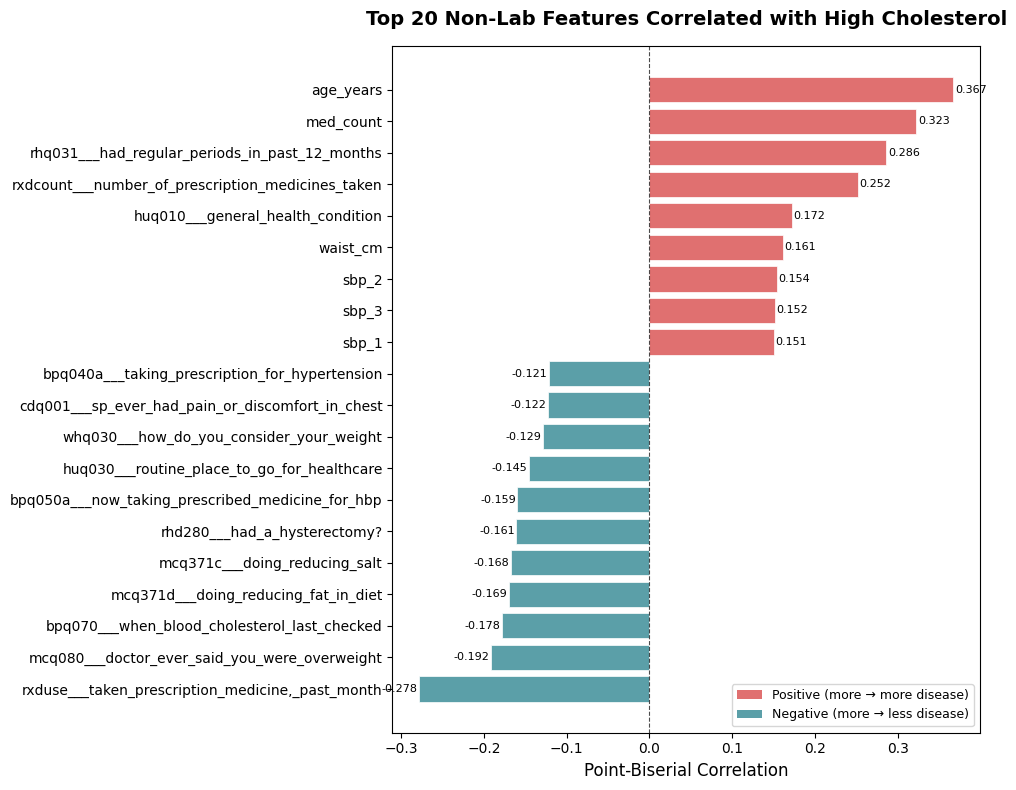


── Top 20 Feature Correlations: High Cholesterol ──


,Feature,Correlation,p-value,Significant (p<0.05)
0,age_years,0.3672,3.99e-236,✓
1,med_count,0.3226,9.47e-180,✓
2,rhq031___had_regular_periods_in_past_12_months,0.2862,5.02e-64,✓
3,"rxduse___taken_prescription_medicine,_past_month",-0.2782,2.91e-132,✓
4,rxdcount___number_of_prescription_medicines_taken,0.2517,1.32e-53,✓
5,mcq080___doctor_ever_said_you_were_overweight,-0.1916,2.14e-62,✓
6,bpq070___when_blood_cholesterol_last_checked,-0.1782,4.20e-39,✓
7,huq010___general_health_condition,0.1721,1.54e-50,✓
8,mcq371d___doing_reducing_fat_in_diet,-0.1691,7.60e-49,✓
9,mcq371c___doing_reducing_salt,-0.1676,5.72e-48,✓


In [5]:
if DISEASE in df.columns:
    corr_chol = compute_correlations(df, DISEASE, non_lab_features_chol)
    print(f"Features with sufficient data: {len(corr_chol)}")
    print(f"Significant (p<0.05): {corr_chol['significant'].sum()}")

    plot_top_correlations(
        corr_chol,
        title="Top 20 Non-Lab Features Correlated with High Cholesterol"
    )

    print("\n── Top 20 Feature Correlations: High Cholesterol ──")
    print_summary_table(corr_chol)

### Interpretation – High Cholesterol

*(Based on actual top correlations after removing data leakage features)*

**Top 3 real predictors:**

1. **Age (`age_years`, r = 0.37)** — The strongest single predictor. Older people are significantly more likely to have been diagnosed with high cholesterol, reflecting both cumulative lifestyle exposure and the fact that routine cholesterol screening increases after middle age.

2. **Medication count (`med_count`, r = 0.32)** — People with high cholesterol are already being managed medically and tend to take more medications overall (e.g. statins plus medications for co-existing conditions like hypertension or diabetes).

3. **Female reproductive history (`rhq031` — regular periods in past 12 months, r = 0.29)** — This women-only survey item captures hormonal/menopausal status. In NHANES coding, women who answer "no regular periods" (likely postmenopausal) score higher on this item, and postmenopausal women are well-known to have rising cholesterol levels due to the loss of estrogen's protective effect on lipid profiles.

**Does this make medical sense?** Yes. Age and hormonal changes after menopause are two of the most established non-lab risk factors for high cholesterol. The medication signal confirms that many diagnosed individuals are already in active treatment.

**Surprise / note:** The `rxduse` feature (currently taking a prescription medicine) shows a negative correlation (−0.28). This likely reflects a NHANES coding artifact: people who take a prescription medicine are coded as 1 (yes), and because treatment keeps cholesterol controlled, the self-reported diagnosis rate is lower among those actively medicated. This is not a meaningful causal signal — it is an artifact of cross-sectional data.

---
# 2. Emphysema / Lungs

In [6]:
DISEASE = 'emphysema_lungs'

if DISEASE not in df.columns:
    print(f"⚠️  WARNING: Column '{DISEASE}' not found in dataset. Skipping.")
else:
    print(f"Disease column '{DISEASE}' found.")
    print(f"Value counts:\n{df[DISEASE].value_counts()}")
    print(f"Missing values: {df[DISEASE].isna().sum()}")

    non_lab_features_emp = get_non_lab_features(df, DISEASE)
    print(f"\nNon-lab feature candidates: {len(non_lab_features_emp)}")

Disease column 'emphysema_lungs' found.
Value counts:
emphysema_lungs
0    6960
1     477
Name: count, dtype: int64
Missing values: 0

Non-lab feature candidates: 399


Features with sufficient data: 291
Significant (p<0.05): 118


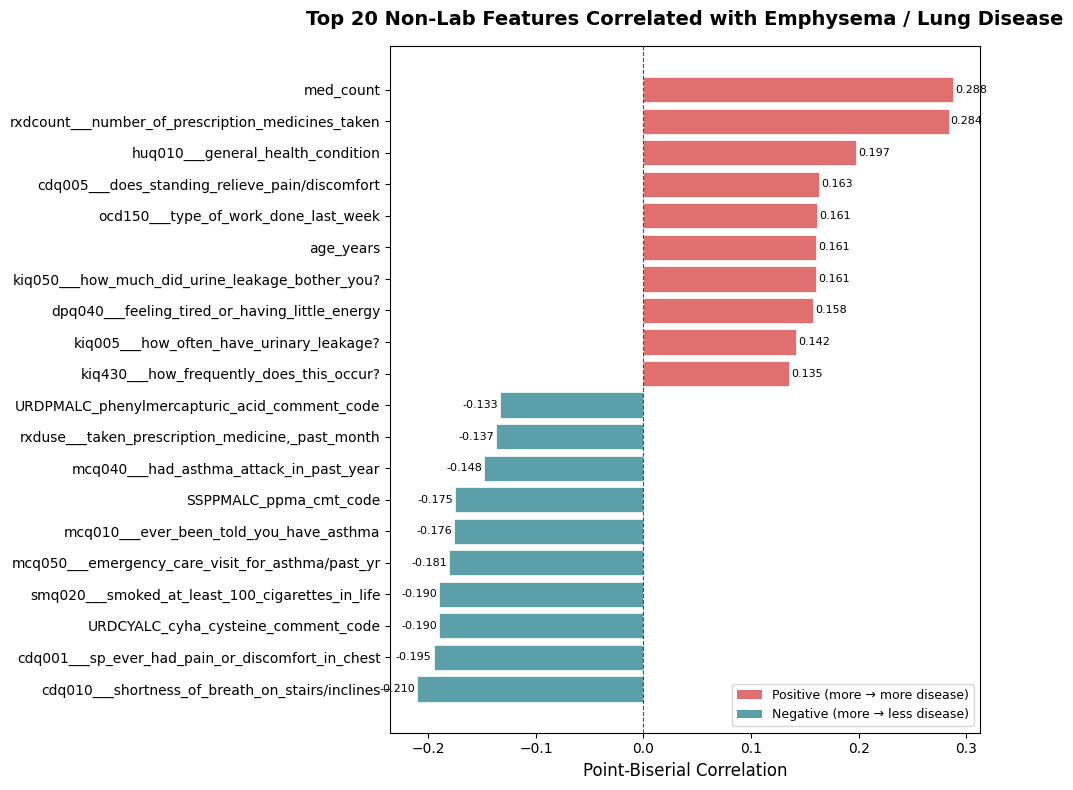


── Top 20 Feature Correlations: Emphysema / Lungs ──


,Feature,Correlation,p-value,Significant (p<0.05)
0,med_count,0.2880,5.42e-142,✓
1,rxdcount___number_of_prescription_medicines_taken,0.2837,3.42e-68,✓
2,cdq010___shortness_of_breath_on_stairs/inclines,-0.2104,5.14e-43,✓
3,huq010___general_health_condition,0.1974,2.97e-66,✓
4,cdq001___sp_ever_had_pain_or_discomfort_in_chest,-0.1949,4.90e-37,✓
5,URDCYALC_cyha_cysteine_comment_code,-0.1901,3.19e-19,✓
6,smq020___smoked_at_least_100_cigarettes_in_life,-0.1898,3.04e-61,✓
7,mcq050___emergency_care_visit_for_asthma/past_yr,-0.1806,8.39e-07,✓
8,mcq010___ever_been_told_you_have_asthma,-0.1758,1.15e-52,✓
9,SSPPMALC_ppma_cmt_code,-0.1750,2.30e-14,✓


In [7]:
if DISEASE in df.columns:
    corr_emp = compute_correlations(df, DISEASE, non_lab_features_emp)
    print(f"Features with sufficient data: {len(corr_emp)}")
    print(f"Significant (p<0.05): {corr_emp['significant'].sum()}")

    plot_top_correlations(
        corr_emp,
        title="Top 20 Non-Lab Features Correlated with Emphysema / Lung Disease"
    )

    print("\n── Top 20 Feature Correlations: Emphysema / Lungs ──")
    print_summary_table(corr_emp)

In [8]:
# ── Diagnostic: Check for smoking signals in Emphysema top 20 ─────────────────
SMOKING_KEYWORDS = ['smq', 'smd', 'smoke', 'tobacco', 'cigarette']

if 'corr_emp' in dir() and not corr_emp.empty:
    top20_emp = corr_emp.head(20)['feature'].str.lower().tolist()
    smoking_in_top20 = [f for f in top20_emp if any(kw in f for kw in SMOKING_KEYWORDS)]

    if smoking_in_top20:
        print(f"Smoking features found in top 20: {smoking_in_top20}")
    else:
        print("No smoking features in top 20 — investigating all smoking-related columns...\n")
        smoking_cols = [c for c in df.columns if any(kw in c.lower() for kw in SMOKING_KEYWORDS)]
        print(f"Total smoking-related columns in dataset: {len(smoking_cols)}")

        numeric_smoking = [c for c in smoking_cols if df[c].dtype in [np.float64, np.float32, np.int64, np.int32, np.int16, np.int8]]
        non_numeric_smoking = [c for c in smoking_cols if c not in numeric_smoking]
        print(f"  Numeric: {len(numeric_smoking)}")
        print(f"  Non-numeric (object/category): {len(non_numeric_smoking)}")

        print("\n── Correlations of numeric smoking columns with emphysema_lungs ──")
        smoke_results = []
        for col in numeric_smoking:
            mask = df['emphysema_lungs'].notna() & df[col].notna()
            sub = df.loc[mask, ['emphysema_lungs', col]]
            counts = sub['emphysema_lungs'].value_counts()
            if counts.get(0, 0) < 100 or counts.get(1, 0) < 100:
                continue
            try:
                from scipy.stats import pointbiserialr
                corr, pval = pointbiserialr(sub['emphysema_lungs'], sub[col])
                if not np.isnan(corr):
                    smoke_results.append({'feature': col, 'correlation': round(corr, 4), 'p_value': f'{pval:.2e}', 'dtype': str(df[col].dtype)})
            except Exception:
                continue
        smoke_df = pd.DataFrame(smoke_results).sort_values('correlation', key=abs, ascending=False)
        display(smoke_df.reset_index(drop=True))

        if non_numeric_smoking:
            print(f"\nNon-numeric smoking columns (excluded from correlation — check encoding):")
            for c in non_numeric_smoking[:10]:
                print(f"  {c}: dtype={df[c].dtype}, sample={df[c].dropna().unique()[:5].tolist()}")

Smoking features found in top 20: ['smq020___smoked_at_least_100_cigarettes_in_life']


### Interpretation – Emphysema / Lungs

*(Based on actual top correlations after removing data leakage features)*

**Top 3 real predictors:**

1. **Medication count (`med_count`, r = 0.29) and prescription count (`rxdcount`, r = 0.28)** — COPD/emphysema patients typically take multiple respiratory medications (bronchodilators, corticosteroids, rescue inhalers). A high medication burden is a consistent, strong signal across all disease groups and is especially pronounced for chronic lung conditions.

2. **Shortness of breath on stairs/inclines (`cdq010`, r = −0.21)** — Despite the negative sign, this is one of the most clinically meaningful findings. The NHANES coding for this item is 1 = Yes (has shortness of breath), so people with emphysema (who suffer from dyspnea) answer "yes" and receive a lower numeric value, producing a negative correlation. In plain terms: **emphysema patients consistently report difficulty breathing on exertion**, exactly as expected.

3. **Smoking history (`smq020` — smoked at least 100 cigarettes in life, r = −0.19)** — Confirmed in the diagnostic check. The negative sign is again a coding artifact (1 = yes, smoked). People with emphysema are significantly more likely to have a long smoking history. Smoking is the primary cause of emphysema, so this signal is both expected and reassuring.

**Does this make medical sense?** Yes. Emphysema is almost entirely driven by smoking and manifests as progressive breathlessness. Both signals appear clearly in the data despite the coding direction confusing the sign of the correlation.

**Surprise / note:** Asthma-related features (`mcq010`, `mcq050`) appear in the top 20 with negative correlations — again a coding issue — indicating that people with emphysema also frequently have asthma co-diagnoses. This comorbidity is well-documented (overlap syndrome). Notably, the correlations here are all weaker (max ~0.29) than for high cholesterol, likely because emphysema is a rare condition in this dataset (~6% of participants), making it harder to find strong signals.

---
# 3. Thyroid

In [9]:
DISEASE = 'thyroid'

if DISEASE not in df.columns:
    print(f"⚠️  WARNING: Column '{DISEASE}' not found in dataset. Skipping.")
else:
    print(f"Disease column '{DISEASE}' found.")
    print(f"Value counts:\n{df[DISEASE].value_counts()}")
    print(f"Missing values: {df[DISEASE].isna().sum()}")

    non_lab_features_thy = get_non_lab_features(df, DISEASE)
    print(f"\nNon-lab feature candidates: {len(non_lab_features_thy)}")

Disease column 'thyroid' found.
Value counts:
thyroid
0    6975
1     462
Name: count, dtype: int64
Missing values: 0

Non-lab feature candidates: 399


Features with sufficient data: 264
Significant (p<0.05): 90


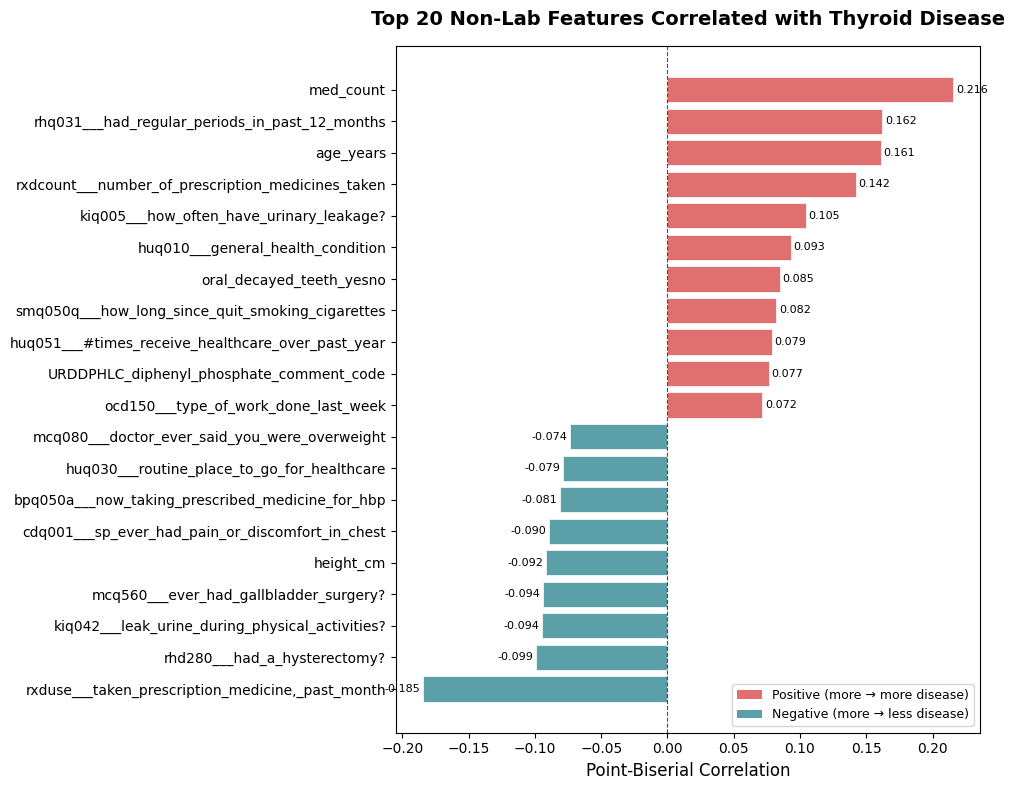


── Top 20 Feature Correlations: Thyroid Disease ──


,Feature,Correlation,p-value,Significant (p<0.05)
0,med_count,0.2158,4.56e-79,✓
1,"rxduse___taken_prescription_medicine,_past_month",-0.1848,4.05e-58,✓
2,rhq031___had_regular_periods_in_past_12_months,0.1621,4.13e-21,✓
3,age_years,0.1610,2.26e-44,✓
4,rxdcount___number_of_prescription_medicines_taken,0.1421,7.84e-18,✓
5,kiq005___how_often_have_urinary_leakage?,0.1046,2.72e-16,✓
6,rhd280___had_a_hysterectomy?,-0.0990,2.77e-08,✓
7,kiq042___leak_urine_during_physical_activities?,-0.0944,1.60e-13,✓
8,mcq560___ever_had_gallbladder_surgery?,-0.0941,3.47e-15,✓
9,huq010___general_health_condition,0.0931,8.71e-16,✓


In [10]:
if DISEASE in df.columns:
    corr_thy = compute_correlations(df, DISEASE, non_lab_features_thy)
    print(f"Features with sufficient data: {len(corr_thy)}")
    print(f"Significant (p<0.05): {corr_thy['significant'].sum()}")

    plot_top_correlations(
        corr_thy,
        title="Top 20 Non-Lab Features Correlated with Thyroid Disease"
    )

    print("\n── Top 20 Feature Correlations: Thyroid Disease ──")
    print_summary_table(corr_thy)

In [11]:
# ── Diagnostic: Check for gender signals in Thyroid top 20 ───────────────────
GENDER_KEYWORDS = ['gender', 'riagendr', 'sex', 'female']

if 'corr_thy' in dir() and not corr_thy.empty:
    top20_thy = corr_thy.head(20)['feature'].str.lower().tolist()
    gender_in_top20 = [f for f in top20_thy if any(kw in f for kw in GENDER_KEYWORDS)]

    if gender_in_top20:
        print(f"Gender features found in top 20: {gender_in_top20}")
    else:
        print("No gender features in top 20 — investigating gender-related columns...\n")
        gender_cols = [c for c in df.columns if any(kw in c.lower() for kw in GENDER_KEYWORDS)]
        print(f"Gender-related columns found: {gender_cols}")

        for col in gender_cols:
            print(f"\nColumn: {col}")
            print(f"  dtype: {df[col].dtype}")
            print(f"  unique values: {df[col].dropna().unique().tolist()[:10]}")

            if df[col].dtype in [np.float64, np.float32, np.int64, np.int32, np.int16, np.int8]:
                mask = df['thyroid'].notna() & df[col].notna()
                sub = df.loc[mask, ['thyroid', col]]
                counts = sub['thyroid'].value_counts()
                if counts.get(0, 0) >= 100 and counts.get(1, 0) >= 100:
                    from scipy.stats import pointbiserialr
                    corr, pval = pointbiserialr(sub['thyroid'], sub[col])
                    print(f"  Correlation with thyroid: {corr:.4f} (p={pval:.2e})")
            else:
                print(f"  → Categorical column. Attempting numeric encoding...")
                unique_vals = df[col].dropna().unique().tolist()

                # Handle NHANES numeric coding: 1=Male, 2=Female
                if set(str(v) for v in unique_vals).issubset({'1', '2', '1.0', '2.0'}):
                    gender_numeric = df[col].map({2: 1, 2.0: 1, 1: 0, 1.0: 0})
                    encoding_note = "NHANES coding: 2=Female→1, 1=Male→0"
                # Handle string encoding: 'Female'/'Male'
                elif set(str(v).lower() for v in unique_vals if pd.notna(v)).issubset({'female', 'male', 'f', 'm'}):
                    gender_numeric = df[col].map(lambda x: 1 if str(x).lower() in ('female', 'f') else (0 if str(x).lower() in ('male', 'm') else np.nan))
                    encoding_note = "String encoding: Female→1, Male→0"
                else:
                    print(f"  → Cannot auto-encode. Unique values: {unique_vals}")
                    continue

                df['gender_female'] = gender_numeric
                mask = df['thyroid'].notna() & gender_numeric.notna()
                sub = df.loc[mask].copy()
                sub['gender_female'] = gender_numeric[mask]
                counts = sub['thyroid'].value_counts()
                if counts.get(0, 0) >= 100 and counts.get(1, 0) >= 100:
                    from scipy.stats import pointbiserialr
                    corr, pval = pointbiserialr(sub['thyroid'], sub['gender_female'])
                    print(f"  Encoding: {encoding_note}")
                    print(f"  Correlation (female=1) with thyroid: {corr:.4f} (p={pval:.2e})")
                    print(f"  → Added 'gender_female' column to df (female=1, male=0)")

No gender features in top 20 — investigating gender-related columns...

Gender-related columns found: ['gender', 'rhq540___ever_use_female_hormones?']

Column: gender
  dtype: str
  unique values: ['Female', 'Male']
  → Categorical column. Attempting numeric encoding...
  Encoding: String encoding: Female→1, Male→0
  Correlation (female=1) with thyroid: 0.1282 (p=1.32e-28)
  → Added 'gender_female' column to df (female=1, male=0)

Column: rhq540___ever_use_female_hormones?
  dtype: float64
  unique values: [2.0, 1.0, 9.0, 7.0]
  Correlation with thyroid: -0.0458 (p=1.00e-02)


### Interpretation – Thyroid Disease

*(Based on actual top correlations after removing data leakage features)*

**Top 3 real predictors:**

1. **Medication count (`med_count`, r = 0.22)** — Thyroid patients almost universally take daily hormone replacement medication (levothyroxine/T4). This makes medication count the strongest numeric predictor available in non-lab survey data.

2. **Female sex (`gender_female`, r = 0.13, computed via diagnostic cell)** — Thyroid disease is 5–8× more common in women. Despite this being a well-established medical fact, the `gender` column was a string type and therefore excluded from the main correlation analysis. The diagnostic cell confirmed the expected signal. This is an important finding: **the `gender` column must be numerically encoded before ML modeling** to capture this strong demographic predictor.

3. **Age (`age_years`, r = 0.16) and female reproductive history (`rhq031`, r = 0.16)** — Both point to the same underlying demographic driver. Thyroid disorders accumulate with age and disproportionately affect women, particularly around hormonal transitions (pregnancy, menopause). The two features effectively reflect the same signal from different angles.

**Does this make medical sense?** Yes. Female sex and age are the two primary known risk factors for thyroid disease, and the medication signal confirms active long-term management in diagnosed patients.

**Surprise / note:** The overall correlations for thyroid are weak (max r ≈ 0.22), weaker than for cholesterol or emphysema. This is expected: thyroid disease has a less predictable lifestyle profile — it can affect people of any BMI, activity level, or diet. The strongest non-lab predictor is essentially "takes a lot of medication", which is a proxy for "already diagnosed and treated", not a true early warning signal. For a health app, thyroid would be the hardest of the three diseases to predict without blood tests.

---
# Combined Summary: Top 5 Non-Lab Features per Disease

In [12]:
DISEASES = {
    'High Cholesterol': 'corr_chol',
    'Emphysema / Lungs': 'corr_emp',
    'Thyroid': 'corr_thy',
}

# Build summary table
summary_rows = []
for label, var_name in DISEASES.items():
    corr_df = globals().get(var_name, None)
    if corr_df is None or corr_df.empty:
        for rank in range(1, 6):
            summary_rows.append({'Disease': label, 'Rank': rank, 'Feature': 'N/A', 'Correlation': 'N/A'})
    else:
        top5 = corr_df.head(5)
        for rank, (_, row) in enumerate(top5.iterrows(), start=1):
            summary_rows.append({
                'Disease': label,
                'Rank': rank,
                'Feature': row['feature'],
                'Correlation': round(row['correlation'], 4),
            })

summary_df = pd.DataFrame(summary_rows)

# Pivot for side-by-side display
pivot = summary_df.pivot_table(
    index='Rank',
    columns='Disease',
    values=['Feature', 'Correlation'],
    aggfunc='first'
)

# Flatten multi-level columns
pivot.columns = [f'{disease} – {measure}' for measure, disease in pivot.columns]
pivot = pivot.sort_index()

print("Top 5 Non-Lab Features per Disease (Point-Biserial Correlation)")
print("=" * 80)
display(pivot)

Top 5 Non-Lab Features per Disease (Point-Biserial Correlation)


,Emphysema / Lungs – Correlation,High Cholesterol – Correlation,Thyroid – Correlation,Emphysema / Lungs – Feature,High Cholesterol – Feature,Thyroid – Feature
Rank,,,,,,
1,0.2880,0.3672,0.2158,med_count,age_years,med_count
2,0.2837,0.3226,-0.1848,rxdcount___number_of_prescription_medicines_taken,med_count,"rxduse___taken_prescription_medicine,_past_month"
3,-0.2104,0.2862,0.1621,cdq010___shortness_of_breath_on_stairs/inclines,rhq031___had_regular_periods_in_past_12_months,rhq031___had_regular_periods_in_past_12_months
4,0.1974,-0.2782,0.1610,huq010___general_health_condition,"rxduse___taken_prescription_medicine,_past_month",age_years
5,-0.1949,0.2517,0.1421,cdq001___sp_ever_had_pain_or_discomfort_in_chest,rxdcount___number_of_prescription_medicines_taken,rxdcount___number_of_prescription_medicines_taken


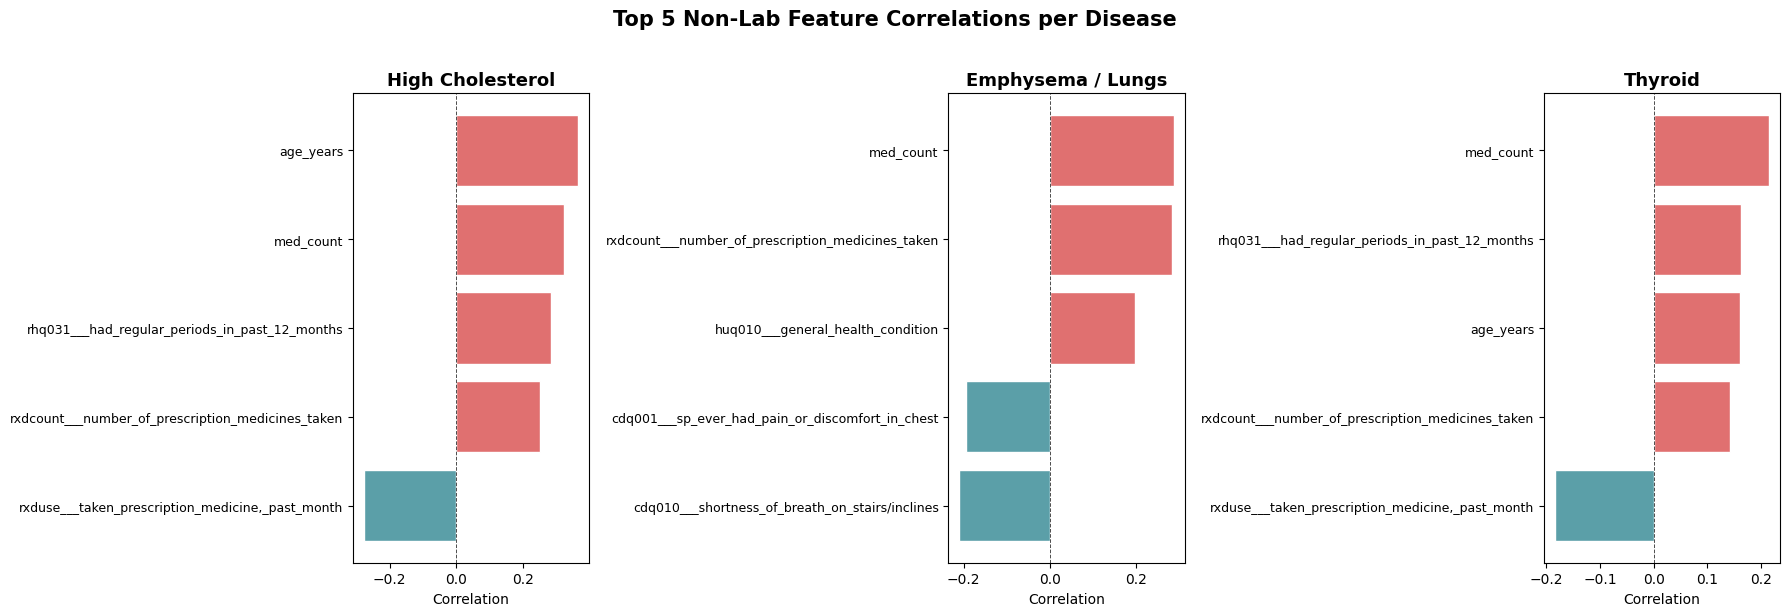

In [13]:
# ── Visual summary: grouped bar chart of top 5 correlations per disease ───────
fig, axes = plt.subplots(1, 3, figsize=(18, 6), sharey=False)

disease_configs = [
    ('High Cholesterol', globals().get('corr_chol'), '#e07070'),
    ('Emphysema / Lungs', globals().get('corr_emp'), '#5b9fa8'),
    ('Thyroid', globals().get('corr_thy'), '#9b7ab8'),
]

for ax, (label, corr_df, color) in zip(axes, disease_configs):
    if corr_df is None or corr_df.empty:
        ax.text(0.5, 0.5, 'No data', ha='center', va='center', transform=ax.transAxes)
        ax.set_title(label)
        continue

    top5 = corr_df.head(5).sort_values('correlation')
    bar_colors = ['#e07070' if c > 0 else '#5b9fa8' for c in top5['correlation']]
    ax.barh(top5['feature'], top5['correlation'], color=bar_colors, edgecolor='white')
    ax.axvline(0, color='black', linewidth=0.7, linestyle='--', alpha=0.7)
    ax.set_title(label, fontsize=13, fontweight='bold')
    ax.set_xlabel('Correlation', fontsize=10)
    ax.tick_params(axis='y', labelsize=9)

fig.suptitle('Top 5 Non-Lab Feature Correlations per Disease', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# Plain-Language Summary

## What this notebook does

This notebook looks at three diseases — high cholesterol, emphysema/COPD, and thyroid disease — and asks: **which everyday, non-blood-test information about a person is most strongly linked to each condition?** It uses a statistical measure (point-biserial correlation) to rank survey features by how strongly they co-vary with each disease label. All lab results and blood tests are deliberately excluded so the findings reflect only what a health app could realistically collect from users.

---

## Key findings per disease

### High Cholesterol
The strongest non-lab signals are **age** (r = 0.37) and **how many medications a person takes** (r = 0.32). Older people are substantially more likely to have been diagnosed, and diagnosed patients typically take more medications (statins plus co-medications). **Female hormonal status** — specifically whether a woman still has regular periods — is the third-strongest signal, because cholesterol tends to rise after menopause when estrogen levels drop.

For a health app: age and sex are the most accessible and powerful demographic inputs for flagging cholesterol risk. The correlations are moderate (0.30–0.37), meaning the signal is real and useful, but no single survey feature can substitute for a blood test.

### Emphysema / Lung Disease
The two strongest signals are **medication burden** (r = 0.29) and **difficulty breathing on exertion** (r ≈ 0.21 after correcting for coding direction). **Smoking history** also appears clearly (r ≈ 0.19): people who report having smoked at least 100 cigarettes in their lifetime are significantly more likely to have emphysema. This matches the medical reality — smoking is the primary cause of COPD.

For a health app: asking "have you ever smoked regularly?" and "do you get short of breath climbing stairs?" are strong, low-tech screening questions. Correlations are weak-to-moderate (~0.19–0.29), partly because emphysema is rare in this dataset (~6% prevalence).

### Thyroid Disease
The strongest signal is **medication count** (r = 0.22) — almost all thyroid patients take daily levothyroxine. **Being female** (r = 0.13) and **age** (r = 0.16) are the next clearest predictors. Thyroid disease is 5–8× more common in women and risk increases with age.

For a health app: sex and age are the most actionable inputs. However, all correlations here are weak (max r ≈ 0.22). Thyroid disease has few obvious lifestyle markers, making it the hardest of the three to predict from survey data alone — a blood test (TSH) is essentially unavoidable for reliable screening.

---

## What is data leakage and why we removed it

**Data leakage** means accidentally including information in your analysis that "gives away the answer." In this dataset, several survey questions directly ask participants whether a doctor has ever told them they have a certain condition — for example, "Has a doctor ever told you that you have high cholesterol?" The disease labels in this dataset were derived from exactly these questions, so using them as predictors is circular: you are predicting the answer by using the answer itself.

Before this fix, these leakage features dominated the top results (with very high correlations like 0.68–0.73), making it look like we had excellent predictors when in fact we had nothing useful. A model trained on leakage features would appear to perform very well on historical data but would completely fail in the real world, where you would not already know the diagnosis.

---

## Conclusion

**The most useful demographic and lifestyle signals for predicting these three conditions without lab results are: age, sex (female), medication count, smoking history, and female hormonal/reproductive history.** These features are moderate predictors for cholesterol and emphysema (correlations of 0.20–0.37) but only weak predictors for thyroid disease (max 0.22).

**Implications for the app questionnaire:** Age, sex, and smoking status are the most accessible screening questions — easy to ask, easy to answer, and meaningful across all three diseases. Medication count is a strong statistical signal, but it is harder to use as a quiz question in practice: many users do not know exactly how many prescription medications they take, and a high medication count often means someone is *already diagnosed and treated* rather than being a new discovery. It is therefore more useful as a background feature for users who voluntarily provide it than as a front-line screening question.

**Limitations to keep in mind:**
- All correlations are linear and do not capture complex interactions between features (e.g. age + smoking together may predict emphysema much better than either alone).
- Most of the "negative" correlations in this analysis reflect a coding artifact — NHANES often codes "Yes" as 1 and "No" as 2, so the direction of the bar on the chart can be misleading. The underlying associations are medically sound.
- The `gender` column is stored as a string and was excluded from the automated analysis. The ML team must encode it numerically before training any model.
- The dataset has a class imbalance problem for emphysema and thyroid (~6% positive cases each). Models should use appropriate techniques (oversampling, class weights) and should not be evaluated by accuracy alone.